In [ ]:
#| hide
from PIL import Image
from solvemail.core import *

# solvemail

> Gmail / Google Workspace email client built on the Gmail API

solvemail is an async Python client for Gmail. It wraps the Gmail REST API in four small classes (`Email`, `Thread`, `Draft`, and `Label`), so you can search your mail, read message bodies and attachments, organize with labels, and send or reply, all with plain method calls.

It is built on [fastgws](https://github.com/AnswerDotAI/fastgws) for OAuth, and runs every call asynchronously, so you `await` each one. Fetching is lazy: an `Email` or `Thread` starts as just an id and loads the rest of itself only when you read a part that needs it. You choose how much comes back with the `fmt` argument: `metadata` for headers and a snippet, `full` for the whole payload, `minimal` for ids and labels, and `raw` for the original RFC 2822 bytes.

## Installation

Install latest from [pypi][pypi]

```sh
$ pip install solvemail
```

[pypi]: https://pypi.org/project/solvemail/

## How to use

solvemail signs in with OAuth 2.0 through [fastgws](https://github.com/AnswerDotAI/fastgws), which expects an OAuth client secret at `~/.config/fastgws/credentials.json`. The fastgws docs cover how to create that file from a Google Cloud project. The first connection opens a browser to authorize the scopes you asked for, then caches the token so later runs don't prompt again.

Create a `Gmail` client with the scopes you need: `readonly` to read and search, `modify` to also add and remove labels, or `full` for everything including permanent deletion. `profile()` returns the signed-in account, with the address on its `email` attribute.

In [ ]:
gmail = Gmail(scopes='full')
profile = await gmail.profile()
me = profile.email
me

'nc@answer.ai'

### Sending and replying

`send` builds and sends a message. The body is markdown and is converted to HTML for you, and `att=` takes a list of file paths. `reply` keeps the conversation threaded by setting the right `In-Reply-To`, `References`, and `Re:` subject; `reply_draft` makes a draft you can review first. Pass `reply_all=True` to cc the other recipients. `forward` re-sends a message, pasting in the original content and re-attaching its files.

In [ ]:
em = await gmail.send(to=me, subj='solvemail html test',
                      body='Hello from **solvemail**!',
                      html='<p>Hello from <b>solvemail</b>!</p>',
                      att=['otter.png'])
await em.reply(body='Cute otter!')

<div class="prose" markdown="1">

```python
Email(19ec726b6b18f114)
```

</div>

### Searching

`search` takes Gmail's own query syntax, the same operators you would type in the Gmail search box: `from:`, `subject:`, `has:attachment`, `is:unread`, `newer_than:7d`, and so on. It returns `Email` objects already filled in to `metadata`, so you get senders, subjects, and snippets without a second call. Use `search_threads` to get whole conversations instead, and `search_drafts` for drafts.

In [ ]:
ems = await gmail.search('has:attachment', max_results=1)
ems

<div class="prose" markdown="1">

| id | from | subj | 📎 | date |
|-|-|-|-|-|
| 19ec726b0b4efb16 | Nathan Cooper <nc@answer.ai> | solvemail html test | 📎 | Sun, 14 Jun 2026 10:21:01 -0700 |

</div>

### Reading emails

Three helpers give you the body at increasing levels of cleanup. `text` is the raw plain-text part as the sender wrote it. `html(clean=True)` returns the HTML with Gmail signatures and quoted reply chains stripped out. `body(clean=True)` flattens that cleaned HTML back to readable text, which is usually what you want for reading or passing to an LLM. Headers are available as attributes once fetched: `frm`, `to`, `subj`, `date`, and `labelIds`.

In [ ]:
em = ems[0]
print(await em.body())

Hello from solvemail!


### Attachments

`attachments` pulls a message's files out as `EmailAttachment` objects, with `filename`, `mimeType`, and `body.size` available before you download anything. Each one is lazy: call `fetch()` to get the bytes, or pass `save=` a folder or filename to write it straight to disk.

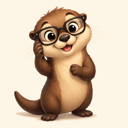

In [ ]:
att = (await em.attachments)[0]
await att.fetch(save='otter_test.png')
Image.open('otter_test.png').resize((128,128))

### Threads

A thread is a conversation: an email and its replies grouped under one id. `search_threads` returns `Thread` objects, each holding its messages as `Email` objects on `.emails`, with `.last` for the most recent. Everything you know about an email works on each message in the thread.

In [ ]:
th = (await gmail.search_threads(max_results=1))[0]
print(await th.last.body())

Cute otter!


### Labels

Labels are Gmail's tags. System labels like `INBOX` and `STARRED` use their name as their id; custom labels get an id like `Label_42`. You can pass a name or an id anywhere a label is expected, and solvemail resolves it for you. `modify` adds and removes labels, and there are shortcuts for the common ones.

In [ ]:
lbl = await gmail.create_label('Otters')
await em.modify(add='Otters', rm='INBOX')
await em.mark_read()
await em.star()
await em.labels

['Otters', 'STARRED', 'SENT']

In [ ]:
#| hide
# clean up
await lbl.delete()
await th.delete()

### Unsubscribe

Newsletters usually carry a `List-Unsubscribe` header saying how to opt out, either a `mailto:` address or a one-click URL. `unsubscribe` reads that header and does whichever the sender offered, so you do not have to hunt for the link buried in the email.

```python
await em.unsubscribe()
```

### Use as an LLM skill

solvemail registers a [pyskills](https://github.com/AnswerDotAI/pyskills) skill, so an LLM host such as solveit can load it and use the read-only API (searching, reading, labels) without write access. Sending, replying, forwarding, and deleting are documented in the skill but are not enabled by default, so you turn them on deliberately when a task needs them.

## Credits

Inspired by [ezgmail](https://github.com/asweigart/ezgmail) by [Al Sweigart](https://inventwithpython.com/) — thanks Al for the great work! The ezgmail repo also has excellent documentation on setting up Gmail API credentials.